<a href="https://colab.research.google.com/github/CIS-522/course-content/blob/W2T2_Homework/tutorials/W2_PyTorchDLN/W2_Homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIS-522 Week 2 Homework


**Instructor:** Konrad Kording

**Content Creators:** Ameet Rahane, Spiros Chavlis

In [ ]:
#@markdown What is your Pennkey and pod? (text, not numbers, e.g. bfranklin)
my_pennkey = 'value' #@param {type:"string"}
my_pod = 'euclidean-wombat' #@param ['Select', 'euclidean-wombat', 'sublime-newt', 'buoyant-unicorn', 'lackadaisical-manatee','indelible-stingray','superfluous-lyrebird','discreet-reindeer','quizzical-goldfish','ubiquitous-cheetah','nonchalant-crocodile','fashionable-lemur','spiffy-eagle','electric-emu','quotidian-lion','astute-jellyfish', 'quantum-herring']

# start timing
import time
try:t0;
except NameError: t0 = time.time()



## Part 1. Recap
This week, we looked at how to create deep fully connected networks in pytorch, covering everything from an introduction to Pytorch tensor operations to deep linear networks. Meet with your pod for 10 minutes to discuss what you learned, what was clear, and what you hope to learn more about. 

In this homework, we will be exploring that a little more. First, we will read a paper by Andrew M. Saxe, James L. McClelland, and Surya Ganguli on _A mathematical theory of semantic development in deep neural networks_. Then, you will design your own linear network to solve a given problem on a dataset. 



# Part 2: A mathematical theory of semantic development in deep neural networks


Read the paper _A mathematical theory of semantic development in deep neural networks_: https://www.pnas.org/content/116/23/11537.short. Take some time and try to contextualize this with respect to the content we covered this week. For more context, watch the talk by Surya Ganguli below. After reading the paper, discuss the main figures with your pod. 

Video available at https://youtube.com/watch?v=SJAvFqHw-hA


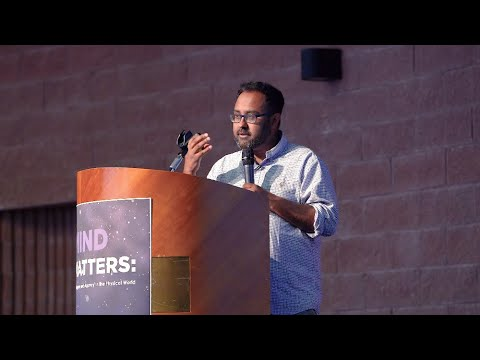

In [ ]:
#@markdown # Dr. Ganguli's talk
from IPython.display import YouTubeVideo
video = YouTubeVideo(id="SJAvFqHw-hA", width=854, height=480, fs=1)
print("Video available at https://youtube.com/watch?v=" + video.id)

video

In [ ]:
# Airtable submission form goes here

#Part 3: Design your own deep network!

In this section, you'll design a deep linear network to perform linear regression in a real dataset. We will provide the data for you.

For the purpose of this homework, we will use the **QSAR fish toxicity dataset** taken from the UCI Machine Learning Repository. For more information you can see [here](https://archive.ics.uci.edu/ml/datasets/QSAR+fish+toxicity) and also read the relevant [publication](http://www.doi.org/10.1080/1062936X.2015.1018938). This study focuses on the development of a new QSAR (Quantitative structure-activity relationship, for more info see [here](https://en.wikipedia.org/wiki/Quantitative_structure%E2%80%93activity_relationship)) model to predict the acute toxicity of diverse chemicals, defined as $LC_{50}$ 96 hours, towards the fathead minnow (Pimephales promelas).

The dataset consists of $908$ number of examples, $6$ molecular features, and $1$ target variable.

Namely, the features are 6 molecular descriptors:

1. CIC0: Complementary Information Content index, neighborhood symmetry of 0-order (encode information regarding heteroatoms)
2. SM1_Dz(Z): the spectral moment of order 1 from Barysz matrix weighted by atomic number (account for heteroatoms, large values more heterogeneity)
3. GATS1i: Geary autocorrelation of lag 1 weighted by ionization potential (shows the number of carbon-carbon bonds)
4. NdsCH: Number of atoms of type dsCH (encode information
about the electrophilic characteristics of chemicals)
5. NdssC: Number of atoms of type dssC (encode information
about the electrophilic characteristics of chemicals)
6. MLogP: Moriguchi octanol-water partition coefficient (a widely accepted estimate of the lipophilicity of organic compounds, which is considered the driving force of narcosis) 

and the target variable is a quantitative response (toxicity), $LC_{50} [-log_{10}(mol/L)]$.

The aim of this small project is to find the linear relationship between these molecular markers and the toxicity. So, you will implement a deep linear network to perform linear regression.

Towards this goal you have to perform the following steps:

1. Download and visualize the dataset. As our samples contain six features, we can perform PCA or any other dimensionality reduction method to visualize our dataset, e.g., [sklearn.decomposition.PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)

```python
# Code example for PCA
X = np.array([[-1, -1],
              [-2, -1],
              [-3, -2],
              [1, 1],
              [2, 1],
              [3, 2]])

pca = decomposition.PCA(n_components=2)  # project in 2D space
pca.fit(X)
Xprojected = pca.transform(X)
```

2. Split the dataset into training and testing subsets (you can split in 80-20 scheme) using [sklearn.model_selection.train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)
3. Write your deep linear network with any approach that is more comfortable for you
4. Choose the hyperparameters (i.e., number of epochs, learning rate, number of layers and nodes per layer)
5. Train the model and give the graph with
  - training and test loss vs. number of epochs
6. Give a plot with the model's performance (actual vs. predicted targets)
7. Train the model again by removing each time one feature. Report what do you observe in terms of performance.

*Hint:* Be sure to use the correct dimensions

In [12]:
#@markdown ## Run this cell to download the dataset: `inputs` and `targets`
import csv
import pandas as pd
import numpy as np

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00504/qsar_fish_toxicity.csv'

df1 = pd.read_csv(url, header=None)

X = np.empty((len(df1), 6))
y = np.empty((len(df1), 1))
for i in range(len(df1)):
    row = df1.iloc[i]
    row = str(row).split()
    vals = row[1].split(";")
    vals = np.array([np.float(i) for i in vals])
    X[i,:] = vals[:-1]
    y[i] = vals[-1]

print(f'input shape: {X.shape}, ' 
      f'targets shape: {y.shape}')

input shape: (908, 6), targets shape: (908, 1)


6 1
Epoch: 1, Loss: 13.917537866303372, Loss test: 13.917537866303372
Epoch: 51, Loss: 1.1380428294745997, Loss test: 1.1380428294745997
Epoch: 101, Loss: 1.1219129118781526, Loss test: 1.1219129118781526
Epoch: 151, Loss: 1.1074911630491688, Loss test: 1.1074911630491688
Epoch: 201, Loss: 1.0940782772533975, Loss test: 1.0940782772533975
Epoch: 251, Loss: 1.0815139848272766, Loss test: 1.0815139848272766
Epoch: 301, Loss: 1.0696872538885558, Loss test: 1.0696872538885558
Epoch: 351, Loss: 1.058519149814595, Loss test: 1.058519149814595
Epoch: 401, Loss: 1.0479520099185415, Loss test: 1.0479520099185415
Epoch: 451, Loss: 1.0379425174763173, Loss test: 1.0379425174763173
Epoch: 501, Loss: 1.0284571958104198, Loss test: 1.0284571958104198
Epoch: 551, Loss: 1.0194694134022881, Loss test: 1.0194694134022881
Epoch: 601, Loss: 1.0109573406718075, Loss test: 1.0109573406718075
Epoch: 651, Loss: 1.0029025142573087, Loss test: 1.0029025142573087
Epoch: 701, Loss: 0.9952887972635787, Loss test: 

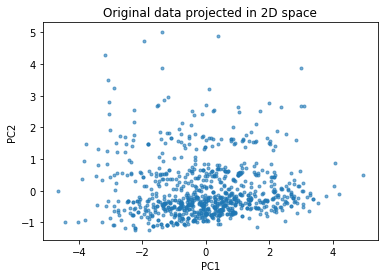

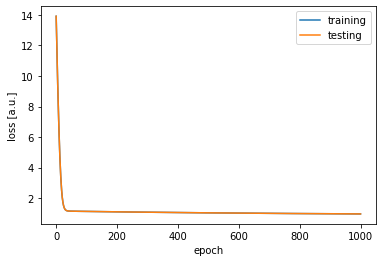

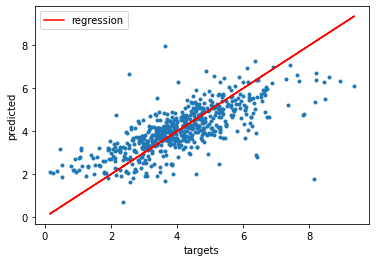

In [21]:
####################################
# TO BE REMOVED
####################################

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import decomposition

N = X.shape[0]  # number of examples
D = X.shape[1]  # number of features

pca = decomposition.PCA(n_components=2)  # project in 2D space
pca.fit(X)
Xprojected = pca.transform(X)

plt.figure()
plt.plot(Xprojected[:,0], Xprojected[:,1], '.', alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Original data projected in 2D space')

X_train, X_test, Y_train, Y_test = train_test_split(X, y,
                                                    test_size=0.33,
                                                    random_state=42)

x_train = torch.tensor(X_train)
y_train = torch.tensor(Y_train)

x_test = torch.tensor(X_train)
y_test = torch.tensor(Y_train)

class Network(nn.Module):

  def __init__(self, input_dim, hidden_1, hidden_2, output_dim):
    super(Network, self).__init__()

    self.input_dim = input_dim
    self.hidden_1 = hidden_1
    self.hidden_2 = hidden_2
    self.output_dim = output_dim

    # A fully-connected network (FCN) with 2 hidden layers
    self.fc1 = nn.Linear(self.input_dim, self.hidden_1)
    self.fc2 = nn.Linear(self.hidden_1, self.hidden_2)
    self.fc3 = nn.Linear(self.hidden_2, self.output_dim)

  def forward(self, x):
    h1 = self.fc1(x)
    h2 = self.fc2(h1)
    out = self.fc3(h2)

    return out


input_dim = x_train.shape[1]
output_dim = y_train.shape[1]
hidden_1 = 20
hidden_2 = 10
model = Network(input_dim, hidden_1, hidden_2, output_dim).double()
print(input_dim, output_dim)


# Training
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(),
                            lr=0.001)

losses = []
losses_test = []
num_epochs=1000

for epoch in range(num_epochs):

  loss = criterion(model(x_train) , y_train)
  loss_test = criterion(model(x_test) , y_test)

  loss.backward()
  optimizer.step()
  optimizer.zero_grad()

  losses.append(loss)
  losses_test.append(loss_test)

  if epoch % 50 == 0:
    print(f'Epoch: {epoch+1}, Loss: {loss.item()}, '
          f'Loss test: {loss_test.item()}')

plt.figure()
plt.plot(losses, label='training')
plt.plot(losses_test, label='testing')
plt.xlabel('epoch')
plt.ylabel('loss [a.u.]')
plt.legend()

y_hat = model(x_test)

plt.figure()
plt.plot(y_test, y_hat.detach().numpy(), '.')
plt.plot(y_test, y_test, 'r', label='regression')
plt.xlabel('targets')
plt.ylabel('predicted')
plt.legend()

### Submission
Double check that the answers have been correctly formatted in the Airtable below, and edit them as desired. **In addition to submitting the form, contribute and reflect on these readings in the student Slack space.**

In [22]:
## Airtable submission form goes here